In [ ]:
from phi.torch.flow import *
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

NU = 0.0002
INLET_PRESSURE = 1.0
OUTLET_PRESSURE = 0.0
DOMAIN_LENGTH = 6.0
DOMAIN_WIDTH = 2.0
OBSTACLE_X0 = 2.0
OBSTACLE_X1 = 3.0
OBSTACLE_Y0 = 0.0
OBSTACLE_Y1 = 1.0

INLET_VELOCITY = 1.0

RESOLUTION_X = 120
RESOLUTION_Y = 40

DOMAIN = Box(x=DOMAIN_LENGTH, y=DOMAIN_WIDTH)
obstacle_box = Box(x=(OBSTACLE_X0, OBSTACLE_X1), y=(OBSTACLE_Y0, OBSTACLE_Y1))
OBSTACLE = Obstacle(obstacle_box)

VELOCITY_BCS = {
    'x-': vec(x=INLET_VELOCITY, y=0),
    'x+': ZERO_GRADIENT,
    'y': 0
}

v0 = StaggeredGrid(
    0,
    x=RESOLUTION_X, y=RESOLUTION_Y,
    bounds=DOMAIN,
    boundary=VELOCITY_BCS
)
p0 = CenteredGrid(
    0,
    x=RESOLUTION_X, y=RESOLUTION_Y,
    bounds=DOMAIN,
    boundary=ZERO_GRADIENT
)

print(f"Velocity grid (v0) bounds: {v0.bounds}")
print(f"Velocity grid (v0) boundaries: {v0.boundary}")
print(f"Obstacle geometry: {OBSTACLE.geometry}")


@jit_compile
def step(v, p, dt=0.05, viscosity=NU):
    v = advect.semi_lagrangian(v, v, dt)
    v = diffuse.explicit(v, viscosity, dt) 
    v, p = fluid.make_incompressible(v, (OBSTACLE,), solve=Solve('auto', 1e-5, x0=p))
    return v, p

v_trj, p_trj = iterate(step, batch(time=100), v0, p0, dt=0.05, viscosity=NU, range=trange)

print("Simulation finished.")
print("Velocity trajectory shape:", v_trj.shape)
print("Pressure trajectory shape:", p_trj.shape)

Velocity grid (v0) bounds: Box(x=(0, 6.0), y=(0, 2.0))
Velocity grid (v0) boundaries: {'x-': (x=1.000, y=0.000), 'x+': zero-gradient, 'y': 0}
Obstacle geometry: Box(x=(2.0, 3.0), y=(0.0, 1.0))


  0%|          | 0/100 [00:00<?, ?it/s]

/home/dan/venvs/torch/lib/python3.11/site-packages/phiml/backend/torch/_torch_backend.py:1128: RuntimeWarning: PyTorch does not support nested tracing. The inner JIT of native(step) will be ignored.
  warnings.warn(f"PyTorch does not support nested tracing. The inner JIT of {self.f.__name__} will be ignored.", RuntimeWarning)


Simulation finished.
Velocity trajectory shape: (xˢ=120, yˢ=40, timeᵇ=101, vectorᶜ=x,y)
Pressure trajectory shape: (timeᵇ=101, xˢ=120, yˢ=40)


In [ ]:
final_velocity.at_centers()["x"].numpy().shape

(120, 40)

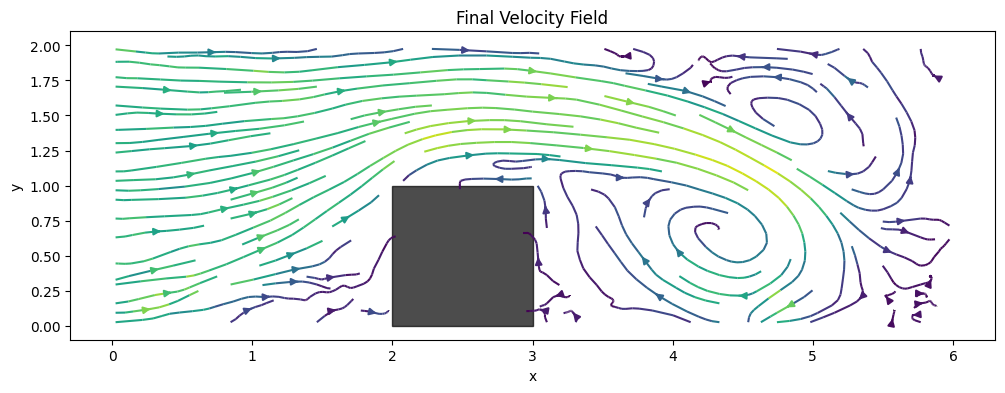

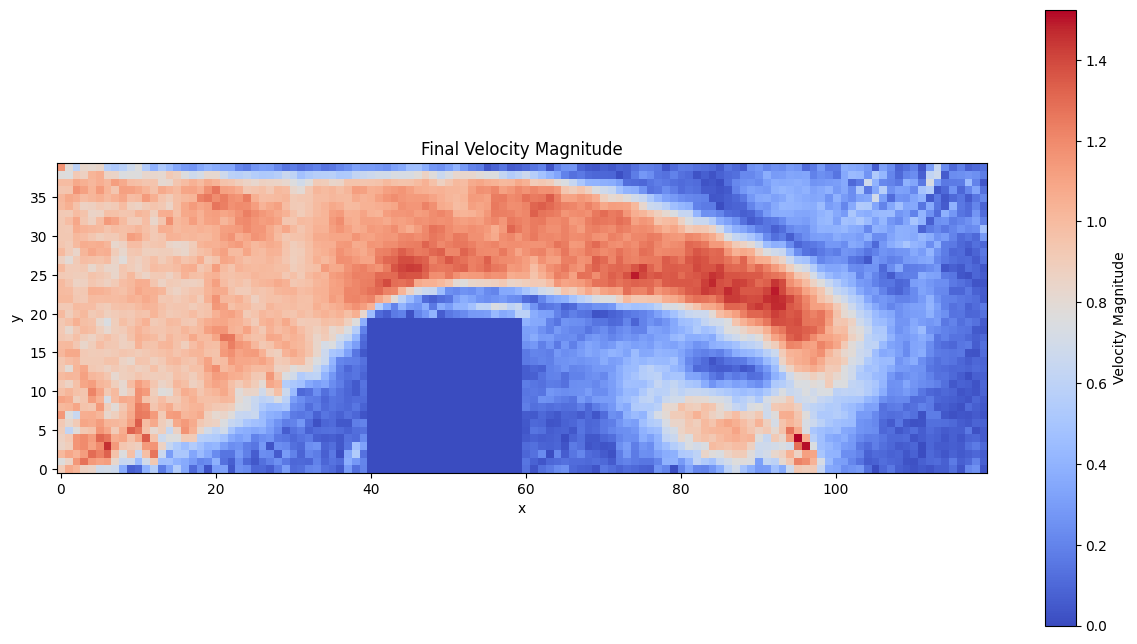

In [126]:
final_velocity = v_trj.time[-1]

# 1. Plot the final velocity field (vectors) and the obstacle
fig = plot(final_velocity, title='Velocity')
fig.set_size_inches(10, 5)
ax = fig.gca()
obstacle_patch = plt.Rectangle((OBSTACLE_X0, OBSTACLE_Y0),
                                OBSTACLE_X1-OBSTACLE_X0,
                                OBSTACLE_Y1-OBSTACLE_Y0,
                                color='black', alpha=0.7)
ax.add_patch(obstacle_patch)
ax.set_title(f'Final Velocity Field')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

def magnitude(field):
    return np.sqrt(field["x"].numpy().T**2 + field["y"].numpy().T**2)

final_v_magnitude = magnitude(final_velocity.at_centers())

plt.figure(figsize=(15, 8))
plt.imshow(final_v_magnitude, cmap='coolwarm', origin='lower')

plt.colorbar(label='Velocity Magnitude')
plt.title('Final Velocity Magnitude')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [113]:
plot(v_trj.time[::2], animate="time")

<Figure size 640x480 with 0 Axes>

In [84]:
!jupyter nbconvert --to script 'offline-training-phiflow.ipynb'

[NbConvertApp] Converting notebook offline-training-phiflow.ipynb to script
[NbConvertApp] Writing 5110 bytes to offline-training-phiflow.py
